### 1. 使用Nummpy实理前馈神经网络，以手写数字识别为例

torch.Size([512, 1, 28, 28]) torch.Size([512]) tensor(-0.4242) <built-in method max of Tensor object at 0x0000027E1BFC72F0>


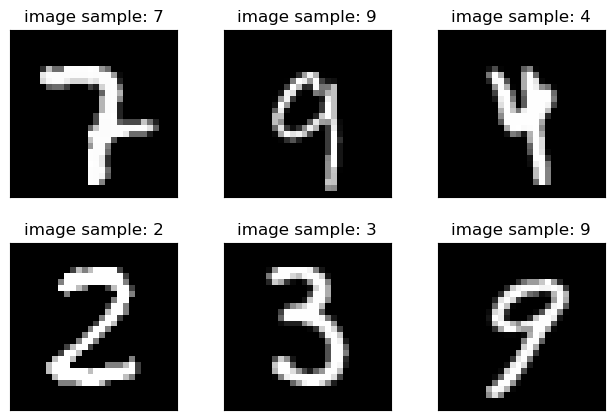

In [38]:
# step1. load dataset
import torch
from torch import nn 
from torch.nn import functional as F
from torch import optim

import torchvision
from matplotlib import pyplot as plt
from utils import plot_curve,plot_image,one_hot
import numpy as np

batch_size = 512
train_loader = torch.utils.data.DataLoader(
    dataset = torchvision.datasets.MNIST('mnist_data/',train=True,download=True,
                               transform=torchvision.transforms.Compose(
                                   [torchvision.transforms.ToTensor(),
                                    torchvision.transforms.Normalize((0.1307,),(0.3081,))] # 使得数据均匀分布在0附近，原本是0-1
                               )),
    batch_size = batch_size,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('mnist_data/', train=False, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize((0.1307,), (0.3081,))]
                                   )),
    batch_size=batch_size, shuffle=False)

x,y = next(iter(train_loader))
print(x.shape ,y.shape, x.min(), x.max)
plot_image(x,y,'image sample')


In [39]:
# step2. build model
# numpy实现
class Net_numpy:
    def __init__(self):
        self.params = {
            'W1': np.random.randn(28*28, 256) * np.sqrt(2. / (28*28)),
            'b1': np.zeros(256),
            'W2': np.random.randn(256, 64) * np.sqrt(2. / 256),
            'b2': np.zeros(64),
            'W3': np.random.randn(64, 10) * np.sqrt(2. / 64),
            'b3': np.zeros(10)
        }
    
    def relu(self, x):
        return np.maximum(0, x)

    def fc(self, x, w, b):
        return np.dot(x, w) + b
    
    def forward(self, x):
        self.x = x  # 保存输入，用于反向传播
        self.h1 = self.relu(self.fc(x, self.params['W1'], self.params['b1']))
        self.h2 = self.relu(self.fc(self.h1, self.params['W2'], self.params['b2']))
        out = self.fc(self.h2, self.params['W3'], self.params['b3'])
        return out
    
    def compute_loss_and_gradients(self, y_pred, y_true):
        """
        计算损失和梯度
        y_pred: 网络预测输出，形状为 [batch_size, 10]
        y_true: 真实标签，one-hot 编码，形状为 [batch_size, 10]
        """
        # 均方误差
        loss = np.mean((y_pred - y_true)**2)
        grad_out = 2 * (y_pred - y_true) / y_pred.shape[0]
        
        # 反向传播
        grads = {}
        grads['W3'] = np.dot(self.h2.T, grad_out)
        grads['b3'] = np.sum(grad_out, axis=0)
        grad_h2 = np.dot(grad_out, self.params['W3'].T)
        grad_h2[self.h2 <= 0] = 0
        grads['W2'] = np.dot(self.h1.T, grad_h2)
        grads['b2'] = np.sum(grad_h2, axis=0)
        grad_h1 = np.dot(grad_h2, self.params['W2'].T)
        grad_h1[self.h1 <= 0] = 0
        grads['W1'] = np.dot(self.x.T, grad_h1)
        grads['b1'] = np.sum(grad_h1, axis=0)
        
        return loss, grads
    
    def parameters(self):
        return self.params

In [40]:
class SGD:
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.params = params
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocities = {key: np.zeros_like(value) for key, value in self.params.items()}

    def step(self, grads):
        for key in self.params:
            grad_with_decay = grads[key] + self.weight_decay * self.params[key]
            self.velocities[key] = self.momentum * self.velocities[key] - self.lr * grad_with_decay
            self.params[key] += self.velocities[key]


0 0 1.8682208221004175
0 10 0.11734362915988181
0 20 0.09274100545910412
0 30 0.08703989488302803
0 40 0.08224201121836355
0 50 0.0792435520629424
0 60 0.0757576799195932
0 70 0.07277101403255103
0 80 0.06957550193188992
0 90 0.06846924344997125
0 100 0.06573794264266102
0 110 0.06218766261088746
1 0 0.06117494510610148
1 10 0.059876070875219664
1 20 0.054910470510031194
1 30 0.05485785385515538
1 40 0.05591033337948309
1 50 0.05330273410184296
1 60 0.050189007711498326
1 70 0.0499869680795343
1 80 0.052392590104227456
1 90 0.047799765449507245
1 100 0.047113445107463105
1 110 0.04664818732182903
2 0 0.046329768424435605
2 10 0.0455488546536234
2 20 0.044494621698566814
2 30 0.042980406284895925
2 40 0.04103760812582889
2 50 0.041864212558769744
2 60 0.044473554567794185
2 70 0.04301863929517261
2 80 0.040764231418294036
2 90 0.04020555690735544
2 100 0.041146392823524953
2 110 0.04047318158487741


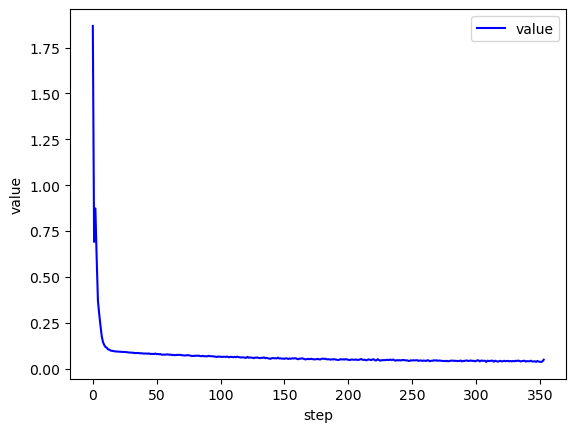

In [41]:
# step3. train model
net = Net_numpy()
optimizer = SGD(net.parameters(), lr=0.002, momentum=0.9, weight_decay = 0.0001)

train_loss = []
for epoch in range(3):
    for batch_idx,(x,y) in enumerate(train_loader):
        # x:[b,1,28,28],y:[512]
        # [b,1,28,28] => [b,feature]=[b,784]
        x = x.view(x.size(0), 28*28).detach().cpu().numpy()
        out = net.forward(x)
        y_onehot = one_hot(y).detach().cpu().numpy()
        loss, grads = net.compute_loss_and_gradients(out, y_onehot)

        # w' = w - lr*grad
        optimizer.step(grads)
        
        train_loss.append(loss)
        if batch_idx % 10 == 0:
            print(epoch, batch_idx, loss)

plot_curve(train_loss)
# 得到比较好的 [w1,b1,w2,b2,w3,b3]

test acc:t 0.741


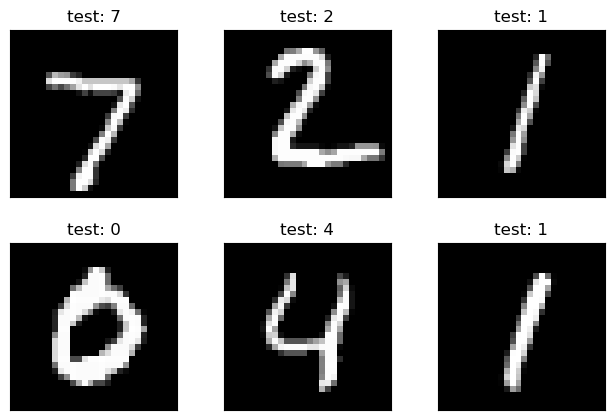

In [42]:
# step4. evaluate model
total_correct = 0
for x, y in test_loader:
    x = x.view(x.size(0), 28*28).detach().cpu().numpy()
    out = net.forward(x)
    pred = np.argmax(out, axis = 1)  # 最大值所在的索引
    total_correct += np.sum(pred == y.numpy())


total_num = len(test_loader.dataset)
acc = total_correct/total_num
print('test acc:t',acc)

x, y = next(iter(test_loader))
x_ = x.view(x.size(0), 28*28).detach().cpu().numpy()
out = net.forward(x_)
pred = np.argmax(out, axis = 1)
plot_image(x, pred, 'test')